In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 16,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "lines.linewidth": 2,
    "lines.markersize": 6,
    "figure.figsize": (5, 4),
})


In [15]:
T = 0.02
data_dir = f"T_{T:.3f}"
csv_file = os.path.join(data_dir, "pairscatter_points.csv")
df = pd.read_csv(csv_file)
df.head()


,conf_id,sweep,site_idx,re,im
0,conf_1,1,1,-0.006609,0.029857
1,conf_1,1,2,0.021583,0.004908
2,conf_1,1,3,-0.023026,-0.018530
3,conf_1,1,4,-0.031050,0.005377
4,conf_1,1,5,-0.050512,0.028381


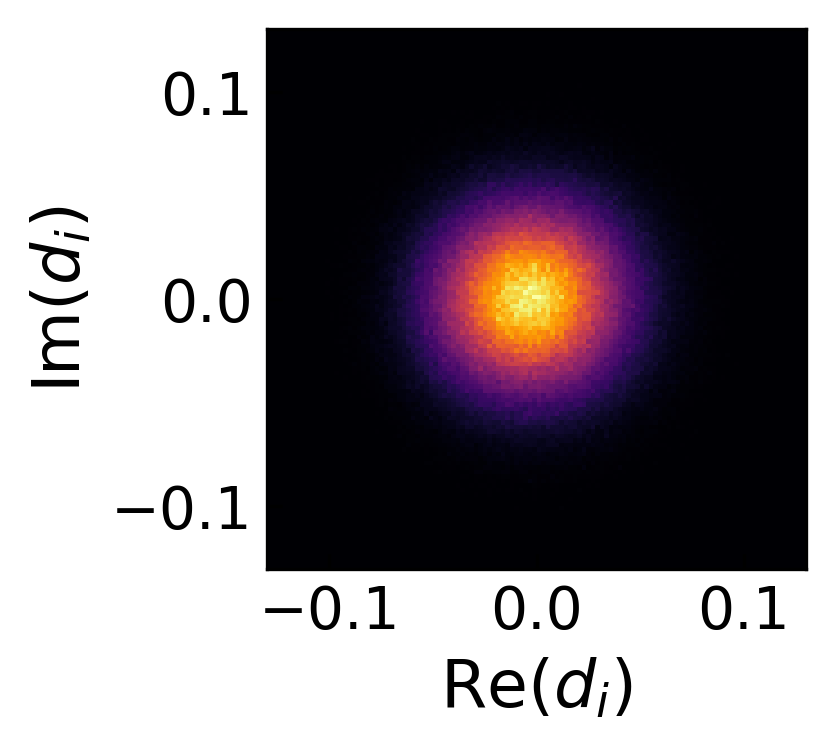

In [16]:
# 2D histogram in complex plane
re = df["re"].to_numpy()
im = df["im"].to_numpy()

n_bins = 120
max_abs = np.max(np.abs(np.concatenate([re, im])))
edges = np.linspace(-max_abs, max_abs, n_bins + 1)

H, xedges, yedges = np.histogram2d(re, im, bins=[edges, edges])

plt.figure(figsize=(3, 3), dpi=300)
pcm = plt.pcolormesh(xedges, yedges, H.T, shading="auto", cmap="inferno")
# cbar = plt.colorbar(pcm)
# cbar.set_label("count")
plt.xlabel(r"Re$(d_i)$")
plt.ylabel(r"Im$(d_i)$")
plt.axis("scaled")
plt.tight_layout()
plt.show()


In [17]:
# # Re(d) distribution
# bins = np.linspace(-max_abs, max_abs, n_bins + 1)
# hist, edges = np.histogram(re, bins=bins, density=True)
# centers = 0.5 * (edges[:-1] + edges[1:])

# plt.figure(figsize=(5, 4), dpi=300)
# plt.plot(centers, hist, "k-")
# plt.xlabel(r"Re$(d_i)$")
# plt.ylabel("Probability density")
# plt.tight_layout()
# plt.show()

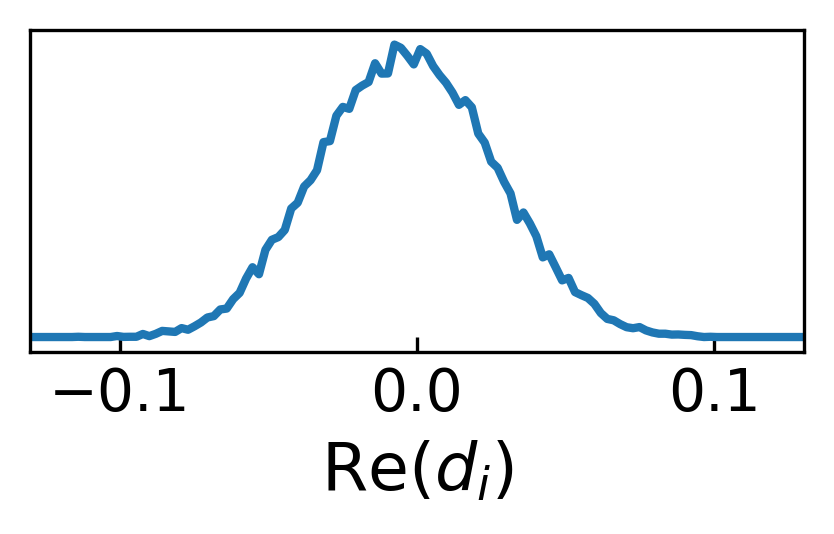

In [18]:
# 1. 计算每个 bin 的中心点坐标
# xedges 和 yedges 是边缘，中心点数量比边缘少 1
x_centers = (xedges[:-1] + xedges[1:]) / 2
y_centers = (yedges[:-1] + yedges[1:]) / 2

# 2. 找到 y_centers 中最接近 0 的索引
# argmin() 会返回绝对值最小处的索引
zero_im_idx = np.abs(y_centers - 0).argmin()

# 3. 从矩阵 H 中提取截面数据
# H 的形状通常是 (nx, ny)，即 (re_bins, im_bins)
# 所以我们需要固定第二个维度 (im)，取所有的第一个维度 (re)
# 注意：np.histogram2d 返回的是 H[x, y]，不用转置直接取列即可
slice_curve = H[:, zero_im_idx]

# 4. 绘制截面图
plt.figure(figsize=(3,2), dpi=300)
plt.plot(x_centers, slice_curve, label=r'Im $\approx$ 0')
plt.xlabel(r"Re$(d_i)$")
# plt.ylabel("Count")
plt.yticks([])
plt.xlim(-max_abs, max_abs)
plt.tight_layout()
plt.show()

In [19]:
# Animation: histogram evolution over sweep
import matplotlib.animation as animation
from IPython.display import display
import matplotlib.patches as patches  # 1. 引入 patches

mode = 'per_sweep'  # 'cumulative' or 'per_sweep'
max_frames = 100
conf_id = 'conf_1'  # e.g. 'conf_1', or None for all

if conf_id is None:
    df_anim = df
else:
    df_anim = df[df['conf_id'] == conf_id]
    if df_anim.empty:
        raise ValueError(f'No data for conf_id={conf_id}')

sweeps = np.sort(df_anim['sweep'].unique())
if len(sweeps) > max_frames:
    idx = np.linspace(0, len(sweeps) - 1, max_frames).astype(int)
    frame_sweeps = sweeps[idx]
else:
    frame_sweeps = sweeps

max_abs = np.max(np.abs(np.concatenate([df_anim['re'].to_numpy(), df_anim['im'].to_numpy()])))
edges = np.linspace(-max_abs, max_abs, n_bins + 1)
extent = [edges[0], edges[-1], edges[0], edges[-1]]

def calc_hist(sweep_val):
    if mode == 'cumulative':
        sub = df_anim[df_anim['sweep'] <= sweep_val]
    else:
        sub = df_anim[df_anim['sweep'] == sweep_val]
    H, _, _ = np.histogram2d(sub['re'], sub['im'], bins=[edges, edges])
    return H

global_max_count = 0
for s in frame_sweeps:
    temp_H = calc_hist(s)
    current_max = temp_H.max()
    if current_max > global_max_count:
        global_max_count = current_max

fig, ax = plt.subplots(figsize=(3, 3), dpi=300)
H0 = calc_hist(frame_sweeps[0])
im = ax.imshow(H0.T, origin='lower', extent=extent, cmap='inferno', aspect='equal')
im.set_clim(vmin=0, vmax=global_max_count if global_max_count > 0 else 1)
# cbar = plt.colorbar(im, ax=ax)
# cbar.set_label('count')
plt.xlabel(r"Re$(d_i)$")
plt.ylabel(r"Im$(d_i)$")
pbar = patches.Rectangle((0, 1.02), 0, 0.04, transform=ax.transAxes, 
                         facecolor='limegreen', edgecolor='none', clip_on=False)
ax.add_patch(pbar)
plt.tight_layout()

def update(sweep_val):
    H = calc_hist(sweep_val)
    im.set_data(H.T)
    current_idx = np.where(frame_sweeps == sweep_val)[0][0]
    total_frames = len(frame_sweeps)
    progress = (current_idx + 1) / total_frames
    pbar.set_width(progress)
    return [im, pbar]

ani = animation.FuncAnimation(fig, update, frames=frame_sweeps, interval=200, blit=False)

out_gif = os.path.join(data_dir, f"pairscatter_hist_{conf_id if conf_id else 'all'}.gif")
try:
    ani.save(out_gif, writer=animation.PillowWriter(fps=24))
    print(f'Saved: {out_gif}')
except Exception as e:
    print(f'GIF save failed: {e}')

display(ani)
plt.close(fig)

Saved: T_0.020/pairscatter_hist_conf_1.gif


In [20]:
df_avg = (
    df
    .groupby(['conf_id', 'site_idx'], as_index=False)
    .agg(
        re_mean=('re', 'mean'),
        re_std =('re', 'std'),
        im_mean=('im', 'mean'),
        im_std =('im', 'std'),
        n_sweep=('re', 'count')
    )
)

df_avg['re_err'] = df_avg['re_std'] / np.sqrt(df_avg['n_sweep'])
df_avg['im_err'] = df_avg['im_std'] / np.sqrt(df_avg['n_sweep'])

df_avg.head()


,conf_id,site_idx,re_mean,re_std,im_mean,im_std,n_sweep,re_err,im_err
0,conf_1,1,-0.003444,0.022128,0.004600,0.023369,336,0.001207,0.001275
1,conf_1,2,-0.000333,0.023982,0.002851,0.025861,336,0.001308,0.001411
2,conf_1,3,-0.002438,0.031155,-0.002211,0.029111,336,0.001700,0.001588
3,conf_1,4,-0.001446,0.032771,-0.000983,0.028913,336,0.001788,0.001577
4,conf_1,5,-0.000864,0.024238,-0.002205,0.025189,336,0.001322,0.001374


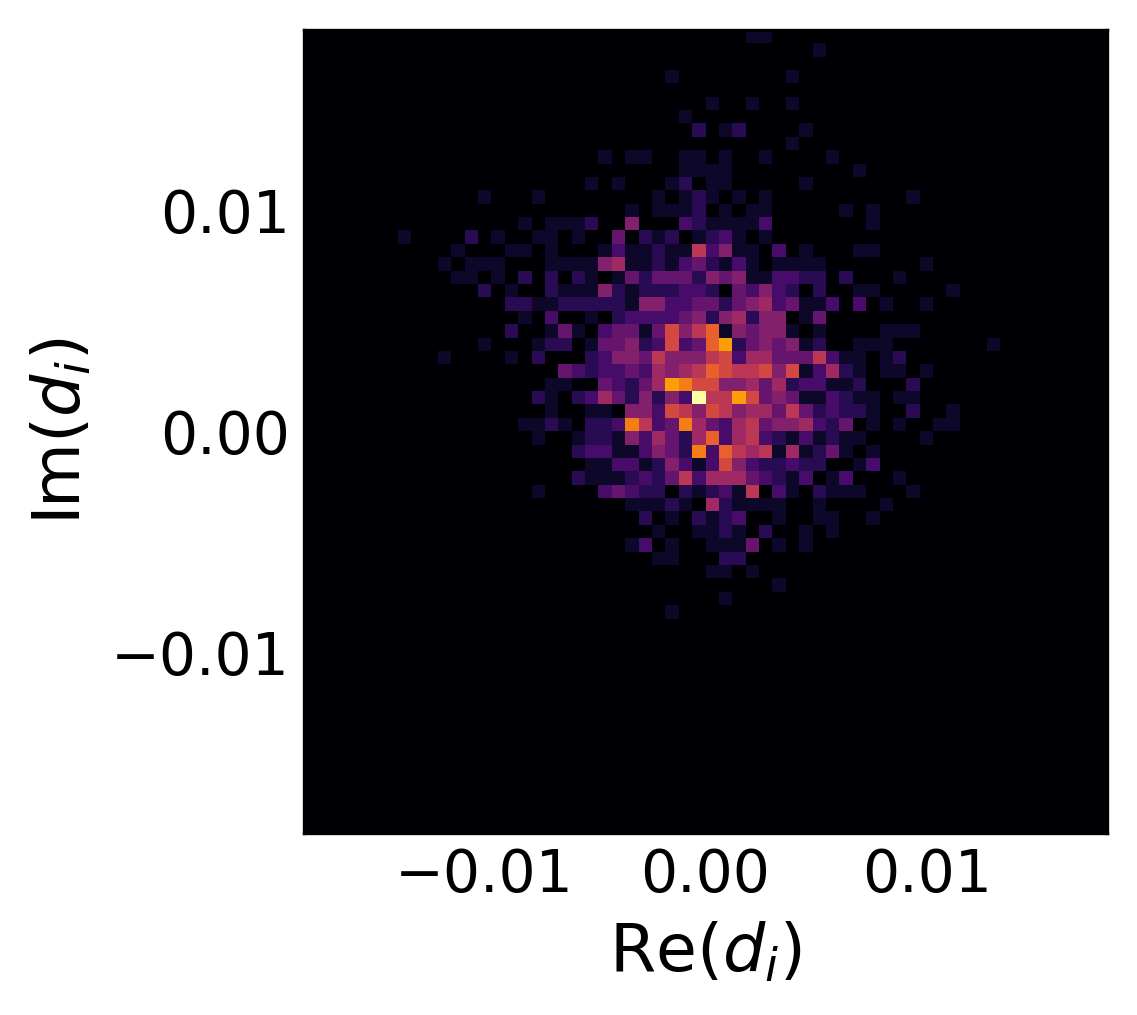

In [21]:
# 2D histogram in complex plane
re = df_avg[df_avg['conf_id']==conf_id]["re_mean"].to_numpy()
im = df_avg[df_avg['conf_id']==conf_id]["im_mean"].to_numpy()

n_bins = 60
max_abs = np.max(np.abs(np.concatenate([re, im])))
edges = np.linspace(-max_abs, max_abs, n_bins + 1)

H, xedges, yedges = np.histogram2d(re, im, bins=[edges, edges])

plt.figure(figsize=(4, 4), dpi=300)
pcm = plt.pcolormesh(xedges, yedges, H.T, shading="auto", cmap="inferno")
# cbar = plt.colorbar(pcm)
# cbar.set_label("count")
plt.xlabel(r"Re$(d_i)$")
plt.ylabel(r"Im$(d_i)$")
plt.axis("scaled")
plt.tight_layout()
plt.show()


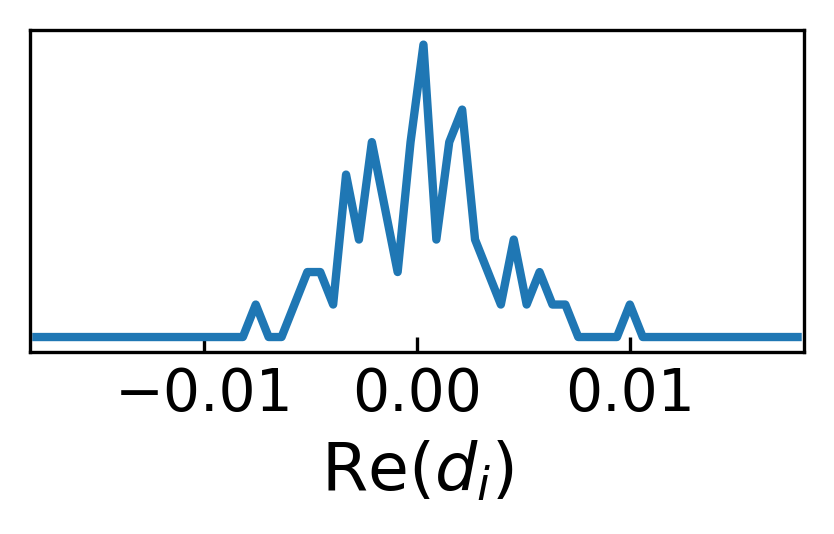

In [22]:
# 1. 计算每个 bin 的中心点坐标
# xedges 和 yedges 是边缘，中心点数量比边缘少 1
x_centers = (xedges[:-1] + xedges[1:]) / 2
y_centers = (yedges[:-1] + yedges[1:]) / 2

# 2. 找到 y_centers 中最接近 0 的索引
# argmin() 会返回绝对值最小处的索引
zero_im_idx = np.abs(y_centers - 0).argmin()

# 3. 从矩阵 H 中提取截面数据
# H 的形状通常是 (nx, ny)，即 (re_bins, im_bins)
# 所以我们需要固定第二个维度 (im)，取所有的第一个维度 (re)
# 注意：np.histogram2d 返回的是 H[x, y]，不用转置直接取列即可
slice_curve = H[:, zero_im_idx]

# 4. 绘制截面图
plt.figure(figsize=(3,2), dpi=300)
plt.plot(x_centers, slice_curve, label=r'Im $\approx$ 0')
plt.xlabel(r"Re$(d_i)$")
# plt.ylabel("Count")
plt.yticks([])
plt.xlim(-max_abs, max_abs)
plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# 9. |d_i| and |<d_i>| distributions across T
# ==========================================

T_list = [0.020, 0.030, 0.040, 0.050]
base_dir = "./"

def load_pairscatter(data_dir, filename="pairscatter_points.csv"):
    file_path = os.path.join(data_dir, filename)
    if not os.path.exists(file_path):
        print(f"Warning: File not found {file_path}")
        return None
    df = pd.read_csv(file_path)
    if df.empty:
        print(f"Warning: Empty file {file_path}")
        return None
    return df

abs_sets = []
abs_mean_sets = []
max_abs = 0.0
max_abs_mean = 0.0

for T in T_list:
    data_dir = os.path.join(base_dir, f"T_{T}")
    df = load_pairscatter(data_dir)
    if df is None:
        continue

    abs_d = np.sqrt(df['re'].to_numpy()**2 + df['im'].to_numpy()**2)
    if abs_d.size > 0:
        max_abs = max(max_abs, float(np.nanmax(abs_d)))
        abs_sets.append((T, abs_d))

    df_avg = (
        df
        .groupby(['conf_id', 'site_idx'], as_index=False)
        .agg(re_mean=('re', 'mean'), im_mean=('im', 'mean'))
    )
    abs_mean = np.sqrt(df_avg['re_mean'].to_numpy()**2 + df_avg['im_mean'].to_numpy()**2)
    if abs_mean.size > 0:
        max_abs_mean = max(max_abs_mean, float(np.nanmax(abs_mean)))
        abs_mean_sets.append((T, abs_mean))

# |d_i| distribution
if len(abs_sets) == 0:
    print("No data for |d_i| distribution.")
else:
    n_bins = 80
    bins = np.linspace(0, max_abs, n_bins + 1)
    centers = 0.5 * (bins[:-1] + bins[1:])
    colors = plt.cm.viridis(np.linspace(0, 1, len(abs_sets)))

    fig, ax = plt.subplots(dpi=300)
    for i, (T, abs_d) in enumerate(abs_sets):
        hist, _ = np.histogram(abs_d, bins=bins, density=True)
        ax.plot(centers, hist, color=colors[i], label=rf"T={T:g}")
    ax.set_xlabel(r'$|d_i|$')
    ax.set_ylabel('Probability density')
    ax.legend(frameon=False, ncol=2)
    plt.show()

# |<d_i>| distribution after sweep average
if len(abs_mean_sets) == 0:
    print("No data for |<d_i>| distribution.")
else:
    n_bins = 80
    bins = np.linspace(0, max_abs_mean, n_bins + 1)
    centers = 0.5 * (bins[:-1] + bins[1:])
    colors = plt.cm.viridis(np.linspace(0, 1, len(abs_mean_sets)))

    fig, ax = plt.subplots(dpi=300)
    for i, (T, abs_m) in enumerate(abs_mean_sets):
        hist, _ = np.histogram(abs_m, bins=bins, density=True)
        ax.plot(centers, hist, color=colors[i], label=rf"T={T:g}")
    ax.set_xlabel(r'$|\langle d_i \rangle|$')
    ax.set_ylabel('Probability density')
    ax.legend(frameon=False, ncol=2)
    plt.show()


No data for |d_i| distribution.
No data for |<d_i>| distribution.


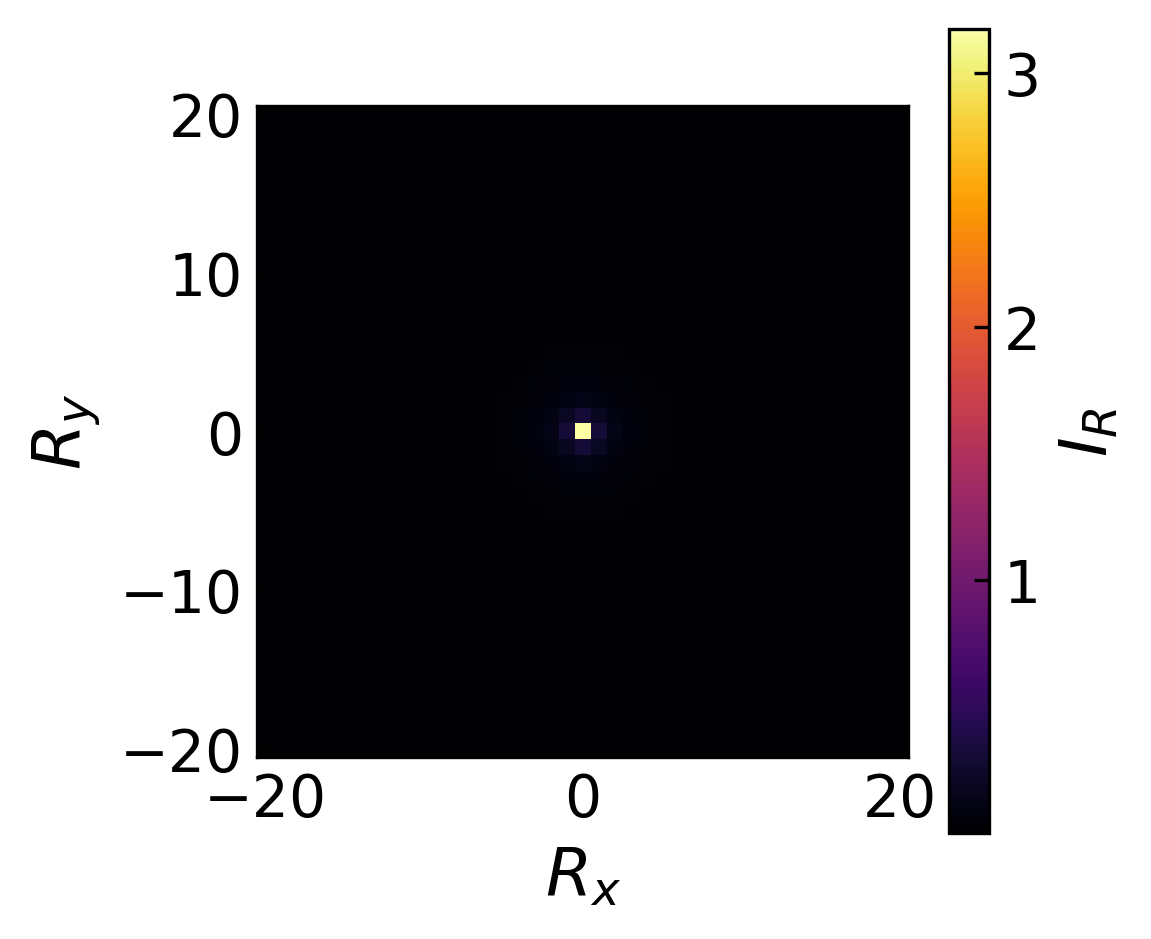

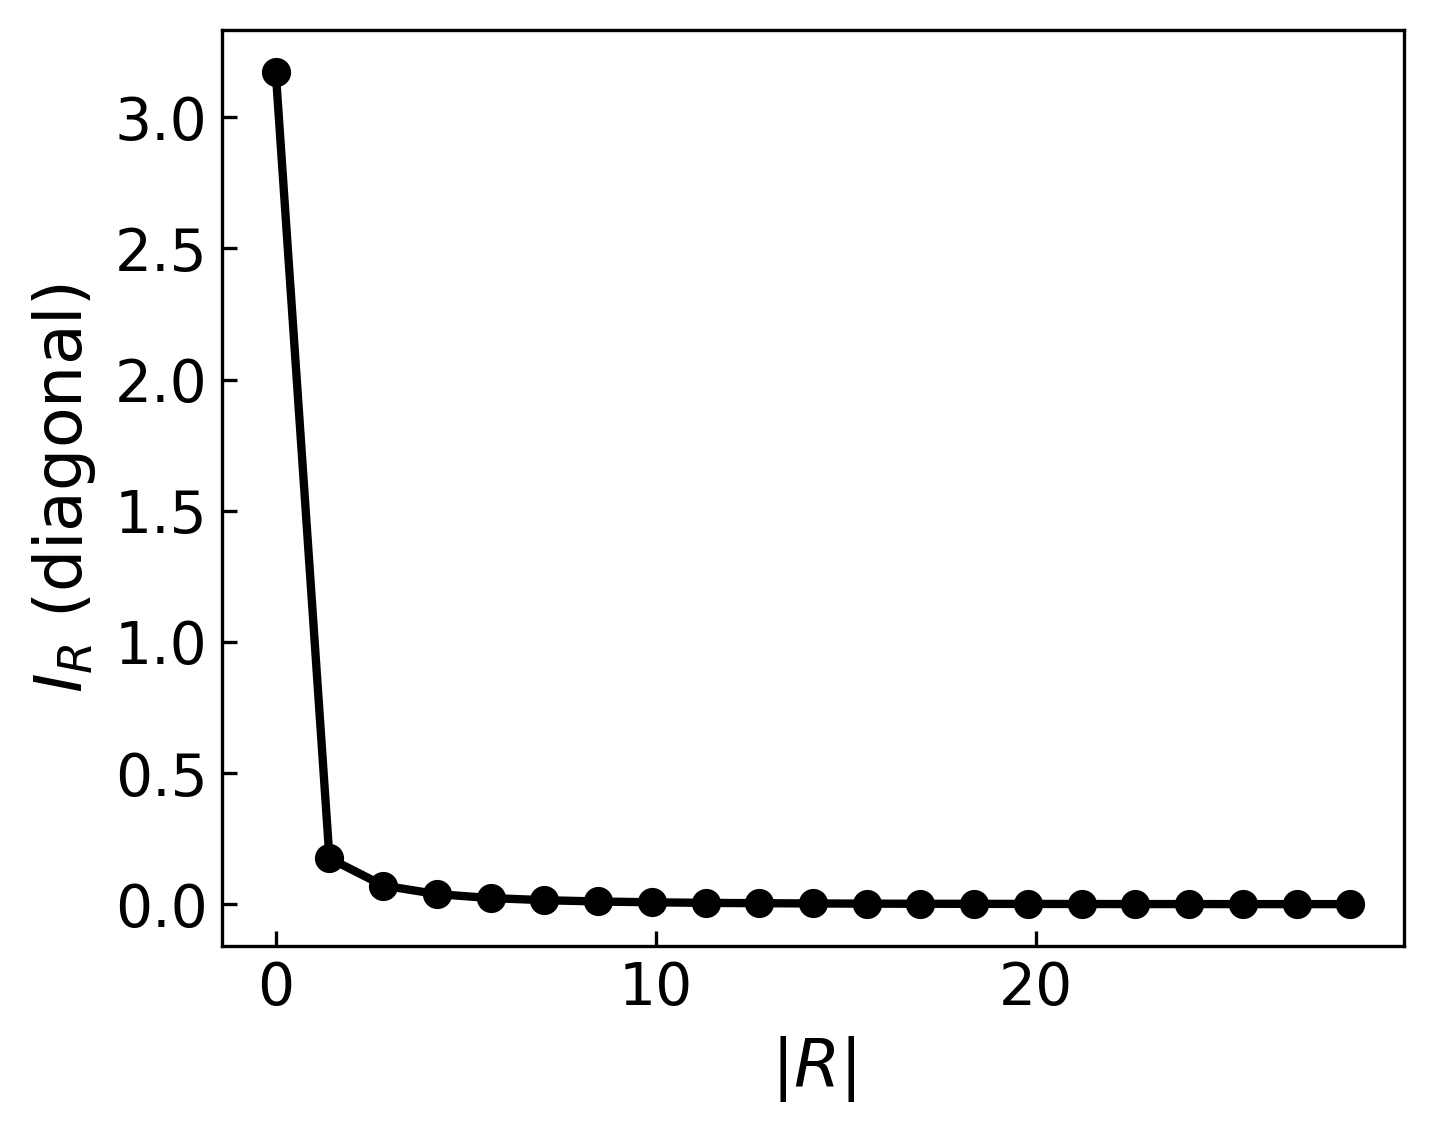

In [24]:
# ==========================================
# 10. Phase mutual information I_R (from sweep fluctuations)
# ==========================================

# Lattice size (periodic BC): max distance is Lx/2, Ly/2
Lx = 40
Ly = 40
T_current = T  # use current temperature
data_dir = f"T_{T_current:.3f}"
csv_file = os.path.join(data_dir, "pairscatter_points.csv")

df = pd.read_csv(csv_file)

n_theta_bins = 24
R_stride = 1
max_sweeps = None  # set to int to subsample sweeps per conf_id

def phase_bins_from_df(df_sweep, Lx, Ly, n_bins):
    idx = df_sweep['site_idx'].to_numpy().astype(int)
    theta = np.mod(np.arctan2(df_sweep['im'].to_numpy(), df_sweep['re'].to_numpy()), 2 * np.pi)
    bins = np.floor(theta / (2 * np.pi) * n_bins).astype(np.int64)
    bins = np.clip(bins, 0, n_bins - 1)

    bmat = np.full((Ly, Lx), -1, dtype=np.int16)
    x = (idx - 1) % Lx
    y = (idx - 1) // Lx
    bmat[y, x] = bins
    return bmat

def mi_from_counts(counts):
    total = counts.sum()
    if total == 0:
        return np.nan
    p12 = counts / total
    p1 = p12.sum(axis=1)
    p2 = p12.sum(axis=0)
    p1p2 = p1[:, None] * p2[None, :]
    mask = p12 > 0
    return float(np.sum(p12[mask] * np.log(p12[mask] / p1p2[mask])))

# Precompute binned phase maps for each sweep in each conf_id
bins_list_all = []
conf_ids = np.sort(df['conf_id'].unique())

for conf_id in conf_ids:
    df_c = df[df['conf_id'] == conf_id]
    sweeps = np.sort(df_c['sweep'].unique())
    if max_sweeps is not None and len(sweeps) > max_sweeps:
        idx = np.linspace(0, len(sweeps) - 1, max_sweeps).astype(int)
        sweeps = sweeps[idx]

    for s in sweeps:
        sub = df_c[df_c['sweep'] == s]
        bins_list_all.append(phase_bins_from_df(sub, Lx, Ly, n_theta_bins))

if len(bins_list_all) == 0:
    raise RuntimeError('No sweep data found for mutual information.')

Rx_vals = np.arange(-Lx // 2, Lx // 2 + 1, R_stride)
Ry_vals = np.arange(-Ly // 2, Ly // 2 + 1, R_stride)
MI_map = np.zeros((len(Ry_vals), len(Rx_vals)))

for iy, Ry in enumerate(Ry_vals):
    for ix, Rx in enumerate(Rx_vals):
        counts = np.zeros((n_theta_bins, n_theta_bins), dtype=np.int64)
        for b0 in bins_list_all:
            b1 = np.roll(b0, shift=(Ry, Rx), axis=(0, 1))
            mask = (b0 >= 0) & (b1 >= 0)
            joint = b0[mask].astype(np.int64) * n_theta_bins + b1[mask].astype(np.int64)
            counts += np.bincount(joint, minlength=n_theta_bins * n_theta_bins).reshape(n_theta_bins, n_theta_bins)
        MI_map[iy, ix] = mi_from_counts(counts)

# 2D map of I_R
fig, ax = plt.subplots(figsize=(4, 3.5), dpi=300)
pcm = ax.pcolormesh(Rx_vals, Ry_vals, MI_map, shading='nearest', cmap='inferno')
cbar = plt.colorbar(pcm, ax=ax)
cbar.set_label(r'$I_R$')
ax.set_xlabel(r'$R_x$')
ax.set_ylabel(r'$R_y$')
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

# Diagonal: R = (r, r)
r_max = min(Lx // 2, Ly // 2)
r_vals = np.arange(0, r_max + 1, R_stride)
center_x = np.where(Rx_vals == 0)[0][0]
center_y = np.where(Ry_vals == 0)[0][0]
r_idx = (r_vals // R_stride).astype(int)
diag_MI = MI_map[center_y + r_idx, center_x + r_idx]
diag_dist = np.sqrt(2) * r_vals

fig, ax = plt.subplots(dpi=300)
ax.plot(diag_dist, diag_MI, '-o', color='black')
ax.set_xlabel(r'$|R|$')
ax.set_ylabel(r'$I_R$ (diagonal)')
plt.tight_layout()
plt.show()


In [25]:
diag_dist

array([ 0.        ,  1.41421356,  2.82842712,  4.24264069,  5.65685425,
        7.07106781,  8.48528137,  9.89949494, 11.3137085 , 12.72792206,
       14.14213562, 15.55634919, 16.97056275, 18.38477631, 19.79898987,
       21.21320344, 22.627417  , 24.04163056, 25.45584412, 26.87005769,
       28.28427125])

In [26]:
diag_MI

array([3.17328115e+00, 1.75815940e-01, 7.20768183e-02, 3.92917506e-02,
       2.43813102e-02, 1.61727068e-02, 1.13143974e-02, 8.18179588e-03,
       6.00967350e-03, 4.72873485e-03, 3.77488741e-03, 2.98230848e-03,
       2.58132956e-03, 2.27049256e-03, 2.02557755e-03, 1.65013074e-03,
       1.45416945e-03, 1.44115183e-03, 1.30740510e-03, 1.25245598e-03,
       1.21161358e-03])

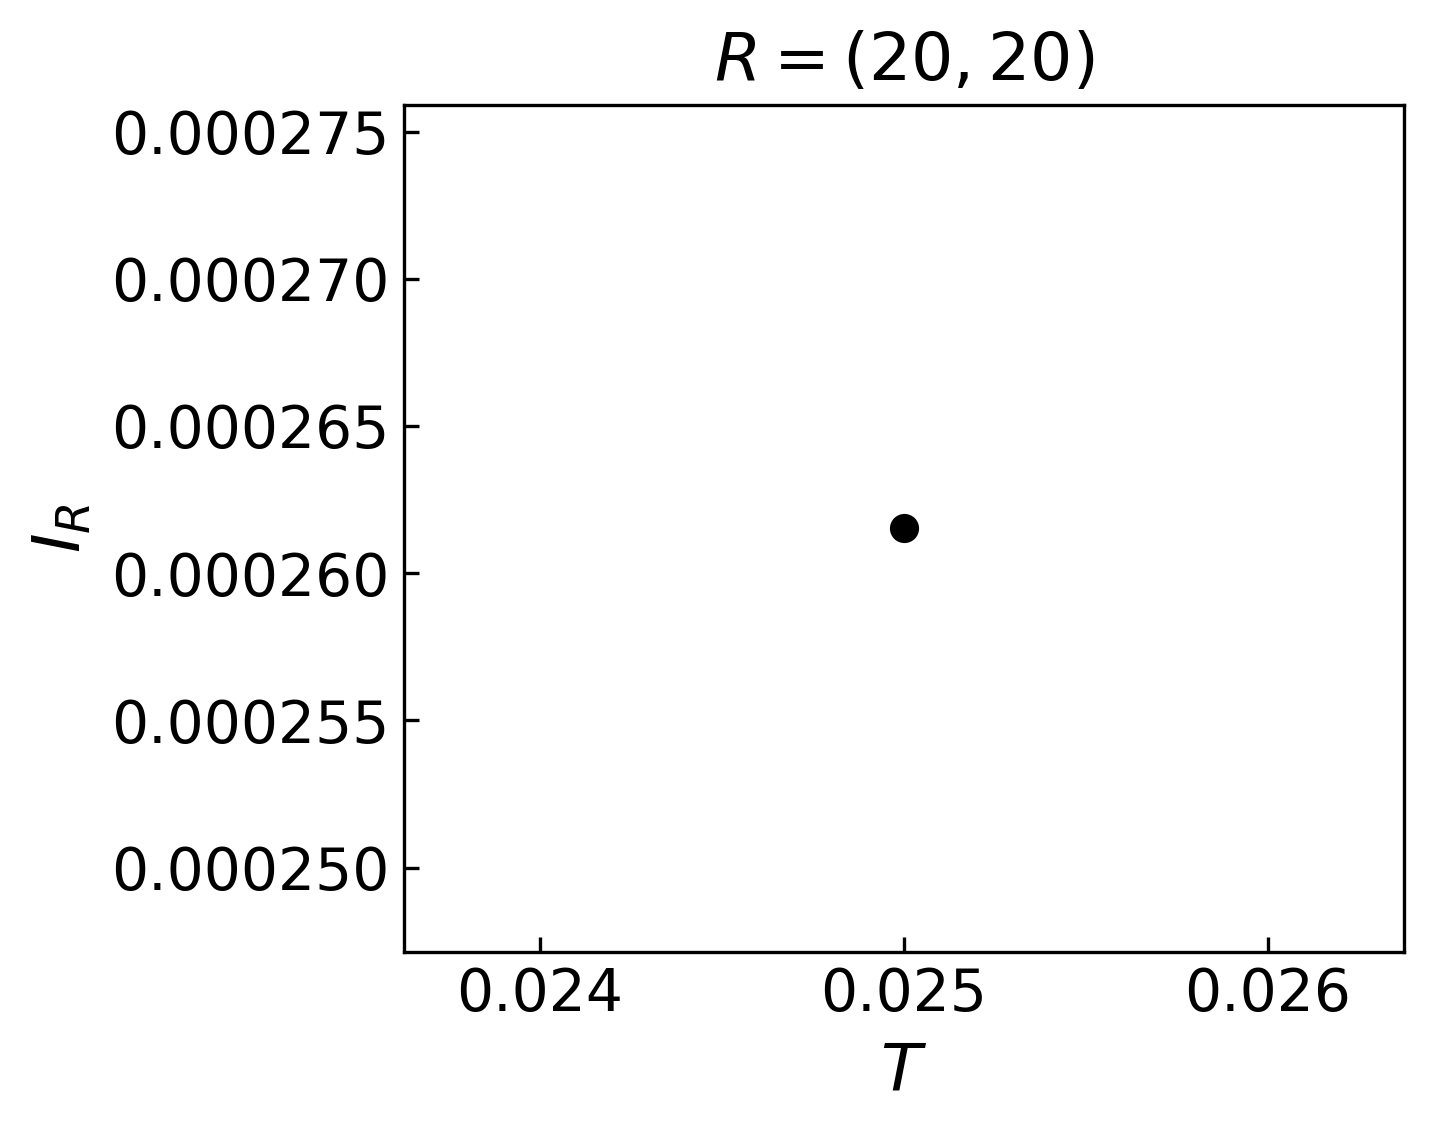

In [27]:
# ==========================================
# 11. I_R vs T at a specified R (from sweep fluctuations)
# ==========================================

if 'phase_bins_from_df' not in globals() or 'mi_from_counts' not in globals():
    raise RuntimeError('Please run the mutual-information cell above first.')

R_target = (20, 20)  # (Rx, Ry)
Lx = 40
Ly = 40
T_list = [0.0001, 0.0005, 0.001, 0.005, 0.01,
          0.015, 0.02, 0.025, 0.03, 0.04, 0.06]
base_dir = "./"
n_theta_bins = 24
max_sweeps = None  # set to int to subsample sweeps per conf_id

def compute_I_R_for_T(T, R_target):
    data_dir = os.path.join(base_dir, f"T_{T}")
    csv_file = os.path.join(data_dir, "pairscatter_points.csv")
    if not os.path.exists(csv_file):
        print(f"Warning: File not found {csv_file}")
        return np.nan
    df = pd.read_csv(csv_file)
    if df.empty:
        print(f"Warning: Empty file {csv_file}")
        return np.nan

    conf_ids = np.sort(df['conf_id'].unique())
    Rx, Ry = R_target

    bins_list_all = []
    for conf_id in conf_ids:
        df_c = df[df['conf_id'] == conf_id]
        sweeps = np.sort(df_c['sweep'].unique())
        if max_sweeps is not None and len(sweeps) > max_sweeps:
            idx = np.linspace(0, len(sweeps) - 1, max_sweeps).astype(int)
            sweeps = sweeps[idx]

        for s in sweeps:
            sub = df_c[df_c['sweep'] == s]
            bins_list_all.append(phase_bins_from_df(sub, Lx, Ly, n_theta_bins))

    if len(bins_list_all) == 0:
        return np.nan

    counts = np.zeros((n_theta_bins, n_theta_bins), dtype=np.int64)
    for b0 in bins_list_all:
        b1 = np.roll(b0, shift=(Ry, Rx), axis=(0, 1))
        mask = (b0 >= 0) & (b1 >= 0)
        joint = b0[mask].astype(np.int64) * n_theta_bins + b1[mask].astype(np.int64)
        counts += np.bincount(joint, minlength=n_theta_bins * n_theta_bins).reshape(n_theta_bins, n_theta_bins)

    return mi_from_counts(counts)

I_vals = []
T_used = []

for T in T_list:
    I_R = compute_I_R_for_T(T, R_target)
    if np.isfinite(I_R):
        T_used.append(T)
        I_vals.append(I_R)

fig, ax = plt.subplots(dpi=300)
ax.plot(T_used, I_vals, '-o', color='black')
ax.set_xlabel(r'$T$')
ax.set_ylabel(r'$I_{R}$')
ax.set_title(rf'$R=({R_target[0]},{R_target[1]})$')
plt.tight_layout()
plt.show()
